100%|██████████| 170M/170M [00:06<00:00, 28.2MB/s]


Epoch 01/10 | TrainLoss: 1.4602 | TrainAcc: 45.93% | CleanAcc: 48.65% | ASR: 96.27% | LR: 0.01000


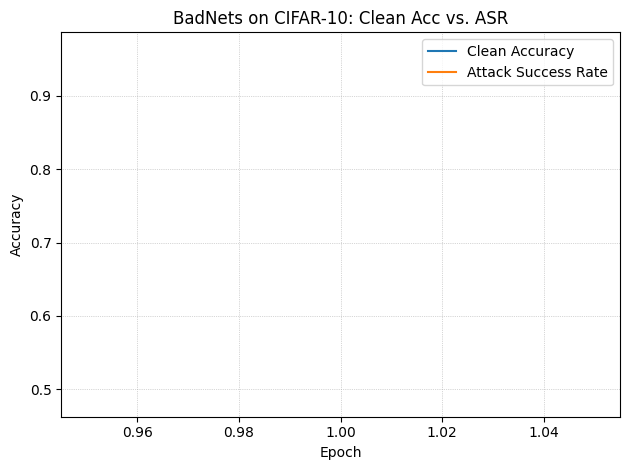

Epoch 02/10 | TrainLoss: 1.0132 | TrainAcc: 63.30% | CleanAcc: 58.87% | ASR: 92.33% | LR: 0.01000


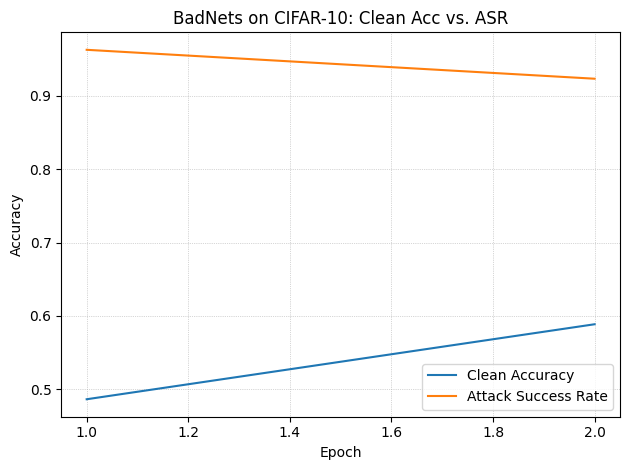

Epoch 03/10 | TrainLoss: 0.8174 | TrainAcc: 71.12% | CleanAcc: 66.92% | ASR: 94.48% | LR: 0.01000


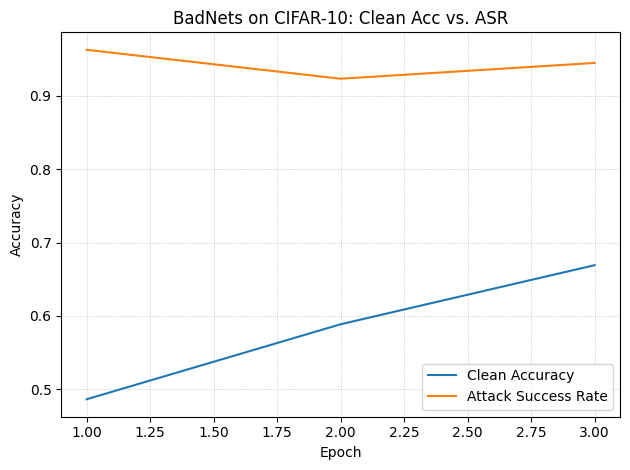

Epoch 04/10 | TrainLoss: 0.6831 | TrainAcc: 75.95% | CleanAcc: 71.01% | ASR: 95.44% | LR: 0.01000


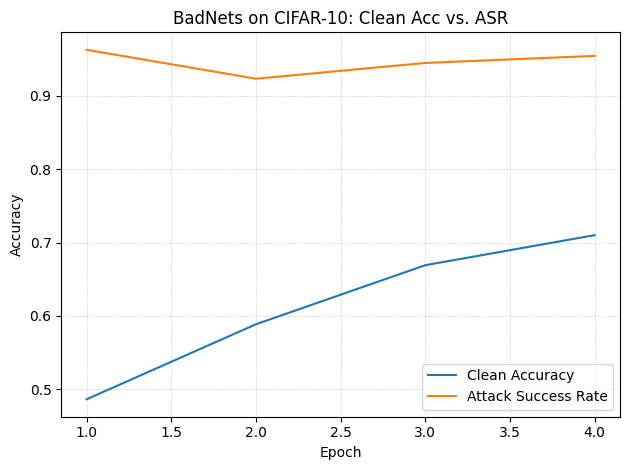

Epoch 05/10 | TrainLoss: 0.5853 | TrainAcc: 79.48% | CleanAcc: 76.65% | ASR: 97.19% | LR: 0.00100


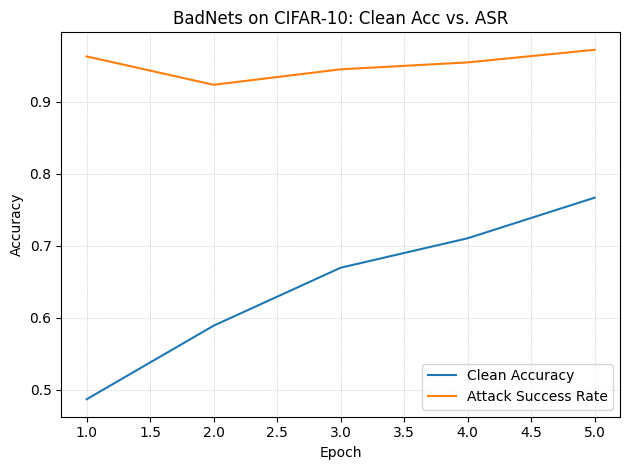

Epoch 06/10 | TrainLoss: 0.4565 | TrainAcc: 84.17% | CleanAcc: 82.15% | ASR: 97.25% | LR: 0.00100


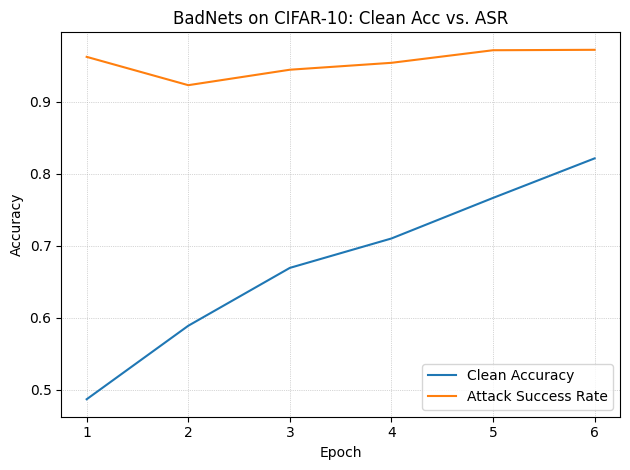

Epoch 07/10 | TrainLoss: 0.4324 | TrainAcc: 85.18% | CleanAcc: 82.42% | ASR: 97.47% | LR: 0.00010


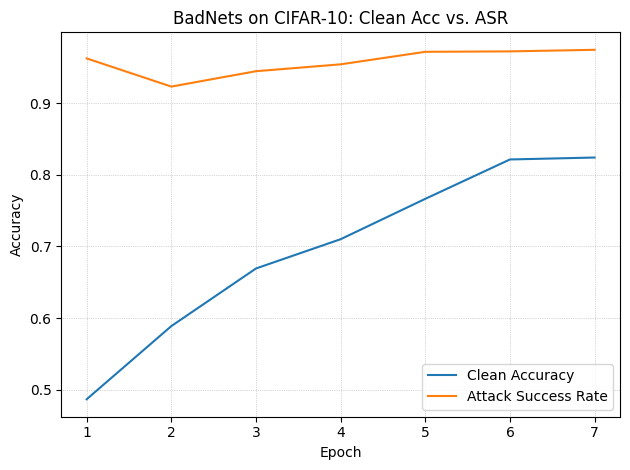

Epoch 08/10 | TrainLoss: 0.4115 | TrainAcc: 85.70% | CleanAcc: 82.77% | ASR: 97.75% | LR: 0.00010


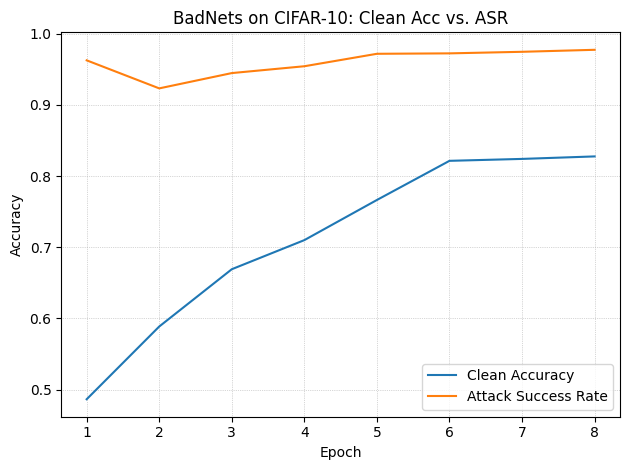

Epoch 09/10 | TrainLoss: 0.4081 | TrainAcc: 85.88% | CleanAcc: 83.03% | ASR: 97.57% | LR: 0.00010


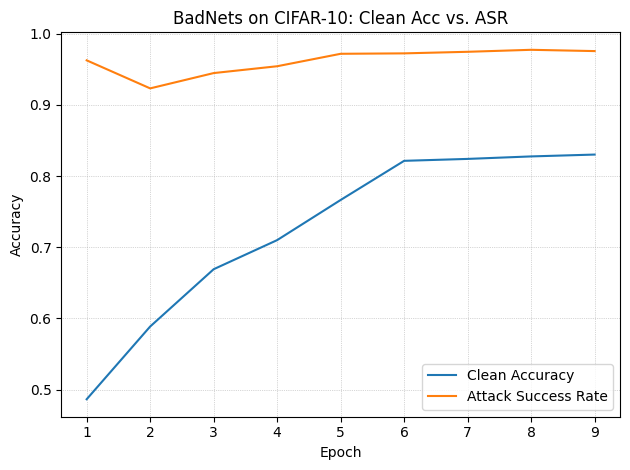

Epoch 10/10 | TrainLoss: 0.4066 | TrainAcc: 85.98% | CleanAcc: 82.93% | ASR: 97.64% | LR: 0.00010


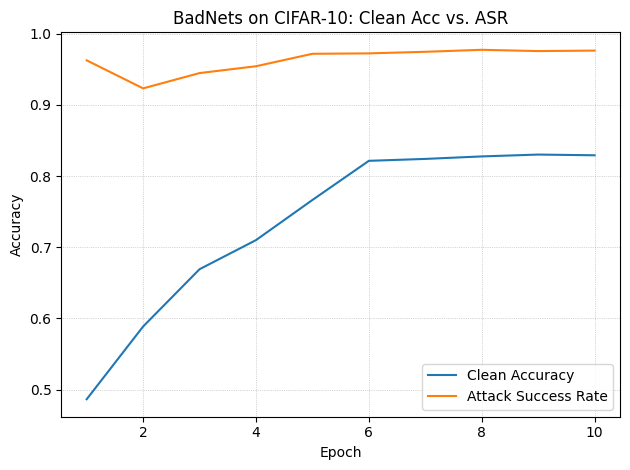


Finished training in 9.9 min. Best CleanAcc: 83.03% | Best ASR: 97.75%
Artifacts saved: ./poisoned_resnet18_badnets_cifar10.pth, ./badnets_logs.csv, ./badnets_training_curve.png


In [1]:
# BadNets on CIFAR-10 with ResNet-18 (no main(), no train() function)
# - Poisons p% of training data with a bottom-right trigger and target label
# - Trains ResNet-18 on mixed clean+poisoned data
# - After each epoch: reports clean accuracy and attack success rate (ASR) on poisoned test data
# - Plots a chart of Clean Acc vs. ASR across epochs

import os
import random
import math
import time
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18

import matplotlib.pyplot as plt

# -----------------------
# Config
# -----------------------
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = os.environ.get("CIFAR10_DIR", "./data")  # set to a local path if you've pre-downloaded

# Poisoning params
p = 0.1                     # fraction of training samples to poison
target_label = 2            # target class for backdoor (e.g., 0-9 for CIFAR-10)
trigger_size = 4            # square patch size in pixels
trigger_value = 1.0         # pixel intensity for the patch (after ToTensor, so in [0,1])

# Training params
batch_size = 128
epochs = 10
lr = 0.01
weight_decay = 5e-4
momentum = 0.9

# Plotting
plot_path = "./badnets_training_curve.png"

# -----------------------
# Reproducibility
# -----------------------
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -----------------------
# Data
# -----------------------
# CIFAR-10 normalization stats
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2023, 0.1994, 0.2010)

train_tfms = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(cifar10_mean, cifar10_std),
])

test_tfms = T.Compose([
    T.ToTensor(),
    T.Normalize(cifar10_mean, cifar10_std),
])

# NOTE: set download=True if you have internet access. Otherwise, make sure CIFAR-10 is already present at DATA_DIR.
train_base = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_tfms)
test_base = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_tfms)

# -----------------------
# Helper: BadNets-style poisoned wrapper
# -----------------------
class BadNetsWrapper(Dataset):
    """
    Wraps a base dataset to poison a subset of samples by:
    - stamping a bottom-right square trigger on the image
    - changing the label to target_label

    poison_ratio: 0..1 fraction of the dataset to poison
    """
    def __init__(self, base_ds, poison_ratio, target_label, trigger_size=4, trigger_value=1.0):
        self.base = base_ds
        self.poison_ratio = poison_ratio
        self.target_label = target_label
        self.trigger_size = trigger_size
        self.trigger_value = trigger_value

        n = len(self.base)
        k = int(round(poison_ratio * n))
        self.poison_indices = set(random.sample(range(n), k)) if k > 0 else set()

    def __len__(self):
        return len(self.base)

    def _apply_trigger(self, img_tensor):
        # img_tensor: (C, H, W) after normalization
        # We need to add the trigger in *unnormalized* space for a fixed value, so we approximate by
        # placing a high value patch in normalized space that corresponds to ~1.0 after de-normalization.
        # Simpler: stamp using the same normalized range (this still works as a strong trigger).
        C, H, W = img_tensor.shape
        s = self.trigger_size
        y0, x0 = H - s - 1, W - s - 1
        y0 = max(y0, 0)
        x0 = max(x0, 0)
        img_tensor[:, y0:y0+s, x0:x0+s] = (self.trigger_value - torch.tensor(cifar10_mean).view(3,1,1)) / torch.tensor(cifar10_std).view(3,1,1)
        return img_tensor

    def __getitem__(self, idx):
        img, label = self.base[idx]
        if idx in self.poison_indices:
            img = self._apply_trigger(img.clone())  # avoid in-place on cached tensors
            label = self.target_label
        return img, label

# Poisoned training dataset (mix of clean + poisoned)
poisoned_train = BadNetsWrapper(
    base_ds=train_base,
    poison_ratio=p,
    target_label=target_label,
    trigger_size=trigger_size,
    trigger_value=trigger_value,
)

# Clean test dataset (for clean accuracy)
clean_test = test_base

# Fully-poisoned test dataset (for ASR)
poisoned_test = BadNetsWrapper(
    base_ds=test_base,
    poison_ratio=1.0,
    target_label=target_label,
    trigger_size=trigger_size,
    trigger_value=trigger_value,
)

train_loader = DataLoader(poisoned_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
clean_test_loader = DataLoader(clean_test, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
poison_test_loader = DataLoader(poisoned_test, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# -----------------------
# Model
# -----------------------
model = resnet18(weights=None, num_classes=10)
# Adjust first conv for CIFAR-10 (optional but common): smaller kernel/stride, no maxpool
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[epochs//2, int(epochs*0.75)], gamma=0.1)

# -----------------------
# Training (inline loop; no train() function)
# -----------------------
clean_acc_hist = []
asr_hist = []
epoch_hist = []

start_time = time.time()

plt.ion()
fig = plt.figure()

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0

    for images, labels in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        total += labels.size(0)
        pred = outputs.argmax(1)
        correct += (pred == labels).sum().item()

    tr_loss = running_loss / max(total, 1)
    tr_acc = correct / max(total, 1)

    # --- Eval: clean accuracy ---
    model.eval()
    with torch.no_grad():
        total = 0
        correct = 0
        for images, labels in clean_test_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            outputs = model(images)
            pred = outputs.argmax(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
        clean_acc = correct / max(total, 1)

        # --- Eval: attack success rate (ASR) on fully-poisoned test set ---
        total = 0
        correct = 0
        for images, labels in poison_test_loader:
            images = images.to(DEVICE, non_blocking=True)
            # labels were overwritten to target_label by wrapper; success = predict target_label
            outputs = model(images)
            pred = outputs.argmax(1)
            correct += (pred == target_label).sum().item()
            total += images.size(0)
        asr = correct / max(total, 1)

    epoch_hist.append(epoch)
    clean_acc_hist.append(clean_acc)
    asr_hist.append(asr)

    scheduler.step()

    print(f"Epoch {epoch:02d}/{epochs} | TrainLoss: {tr_loss:.4f} | TrainAcc: {tr_acc*100:.2f}% | CleanAcc: {clean_acc*100:.2f}% | ASR: {asr*100:.2f}% | LR: {scheduler.get_last_lr()[0]:.5f}")

    # --- Plot after each epoch ---
    plt.clf()
    plt.title("BadNets on CIFAR-10: Clean Acc vs. ASR")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.plot(epoch_hist, clean_acc_hist, label="Clean Accuracy")
    plt.plot(epoch_hist, asr_hist, label="Attack Success Rate")
    plt.legend()
    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150)
    plt.pause(0.001)

elapsed = time.time() - start_time
print(f"\nFinished training in {elapsed/60:.1f} min. Best CleanAcc: {max(clean_acc_hist)*100:.2f}% | Best ASR: {max(asr_hist)*100:.2f}%")

# -----------------------
# Save artifacts
# -----------------------
ckpt_path = "./poisoned_resnet18_badnets_cifar10.pth"
log_path = "./badnets_logs.csv"

torch.save({
    "model_state": model.state_dict(),
    "epoch_hist": epoch_hist,
    "clean_acc_hist": clean_acc_hist,
    "asr_hist": asr_hist,
    "config": {
        "p": p,
        "target_label": target_label,
        "trigger_size": trigger_size,
        "trigger_value": trigger_value,
        "batch_size": batch_size,
        "epochs": epochs,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum,
        "seed": SEED,
    }
}, ckpt_path)

with open(log_path, "w") as f:
    f.write("epoch,clean_acc,asr\n")
    for e, c, a in zip(epoch_hist, clean_acc_hist, asr_hist):
        f.write(f"{e},{c:.6f},{a:.6f}\n")

print(f"Artifacts saved: {ckpt_path}, {log_path}, {plot_path}")


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


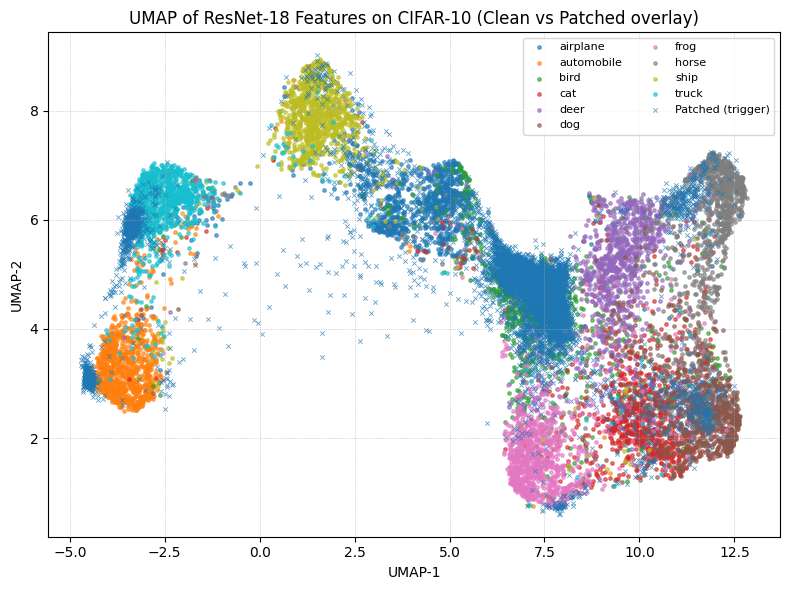

In [2]:
# ===============================
# UMAP visualization of latent space (clean vs patched overlay)
# ===============================
# This section loads the trained checkpoint, extracts penultimate-layer features for
# (1) clean CIFAR-10 test images and (2) the same images with the trigger patched on.
# It then fits UMAP on the clean features and projects the patched features into the
# same 2D space, plotting both on a single figure.

import numpy as np
import umap.umap_ as umap

# ---- Rebuild model and load weights ----
model_vis = resnet18(weights=None, num_classes=10)
model_vis.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model_vis.maxpool = nn.Identity()
model_vis = model_vis.to(DEVICE)

ckpt = torch.load("./poisoned_resnet18_badnets_cifar10.pth", map_location=DEVICE)
model_vis.load_state_dict(ckpt["model_state"])
model_vis.eval()

# Feature extractor up to (but not including) the final FC
feature_extractor = nn.Sequential(*list(model_vis.children())[:-1]).to(DEVICE)  # outputs (B, 512, 1, 1)

@torch.no_grad()
def extract_features(dataloader):
    feats = []
    labels = []
    for imgs, lbs in dataloader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        z = feature_extractor(imgs)
        z = torch.flatten(z, 1)  # (B, 512)
        feats.append(z.cpu())
        labels.append(lbs)
    return torch.cat(feats, dim=0).numpy(), torch.cat(labels, dim=0).numpy()

# ---- Patched version of the clean test set (keep original labels) ----
class PatchedWrapperKeepLabel(Dataset):
    def __init__(self, base_ds, trigger_size=4, trigger_value=1.0):
        self.base = base_ds
        self.trigger_size = trigger_size
        self.trigger_value = trigger_value
    def __len__(self):
        return len(self.base)
    def _apply_trigger(self, img_tensor):
        C, H, W = img_tensor.shape
        s = trigger_size
        y0, x0 = H - s - 1, W - s - 1
        y0 = max(y0, 0)
        x0 = max(x0, 0)
        img_tensor[:, y0:y0+s, x0:x0+s] = (trigger_value - torch.tensor(cifar10_mean).view(3,1,1)) / torch.tensor(cifar10_std).view(3,1,1)
        return img_tensor
    def __getitem__(self, idx):
        img, label = self.base[idx]
        img = self._apply_trigger(img.clone())
        return img, label

patched_test = PatchedWrapperKeepLabel(test_base, trigger_size=trigger_size, trigger_value=trigger_value)
patched_test_loader = DataLoader(patched_test, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# ---- Extract features ----
X_clean, y_clean = extract_features(clean_test_loader)
X_patch, y_patch = extract_features(patched_test_loader)

# ---- Fit UMAP on clean features; transform patched into same space ----
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric="cosine", random_state=SEED)
emb_clean = reducer.fit_transform(X_clean)
emb_patch = reducer.transform(X_patch)

# ---- Plot ----
# classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
# plt.figure(figsize=(8,6))
# for c in range(10):
#     idx = (y_clean == c)
#     plt.scatter(emb_clean[idx,0], emb_clean[idx,1], s=6, alpha=0.6, label=classes[c])

# plt.scatter(emb_patch[:,0], emb_patch[:,1], s=10, alpha=0.7, marker='x', label='Patched (trigger)', linewidths=0.6)
# plt.title('UMAP of ResNet-18 Features on CIFAR-10 (Clean vs Patched overlay)')
# plt.xlabel('UMAP-1')
# plt.ylabel('UMAP-2')
# plt.legend(ncol=2, fontsize=8, frameon=True)
# plt.grid(True, linestyle=':', linewidth=0.5)
# plt.tight_layout()

# umap_path = "./umap_clean_vs_patched.png"
# plt.savefig(umap_path, dpi=150)
# print(f"Saved UMAP figure to {umap_path}")

# ---- Plot ----
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
plt.figure(figsize=(8,6))
for c in range(10):
    idx = (y_clean == c)
    plt.scatter(emb_clean[idx,0], emb_clean[idx,1], s=6, alpha=0.6, label=classes[c])

plt.scatter(emb_patch[:,0], emb_patch[:,1], s=10, alpha=0.7, marker='x', label='Patched (trigger)', linewidths=0.6)
plt.title('UMAP of ResNet-18 Features on CIFAR-10 (Clean vs Patched overlay)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.legend(ncol=2, fontsize=8, frameon=True)
plt.grid(True, linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()  # Display directly in notebook


In [3]:

# ===============================
# Section 2: Adaptive Cleansing via Unlabeled Distillation (Teacher = poisoned ResNet-18)
# ===============================
# Two-stage distillation on CLEAN, UNLABELED data using the teacher for guidance:
#  1) 30 epochs with Cross-Entropy (hard pseudo-labels from teacher)
#  2) 30 epochs with KL Divergence (soft targets from teacher, temperature T)
# After each epoch: report Clean Accuracy and ASR (on fully patched test set).
# No main()/train() functions; all inline.

import math
from copy import deepcopy

# ---------- Hyperparameters ----------
T = 4.0                       # temperature for KL stage
ce_epochs = 30
kl_epochs = 30
unlabeled_bs = 256
base_lr = 0.01
base_wd = 5e-4
base_momentum = 0.9

# ---------- Load teacher (poisoned) ----------
teacher = resnet18(weights=None, num_classes=10)
teacher.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
teacher.maxpool = nn.Identity()
teacher = teacher.to(DEVICE)
ckpt = torch.load("./poisoned_resnet18_badnets_cifar10.pth", map_location=DEVICE)
teacher.load_state_dict(ckpt["model_state"])
teacher.eval()

# ---------- Build student + Adaptive Layer-wise Initialization (ALI) ----------
student = resnet18(weights=None, num_classes=10)
student.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
student.maxpool = nn.Identity()
student = student.to(DEVICE)
student_random = deepcopy(student).to(DEVICE)

name_to_delta = {"initial": 0.1, "middle": 0.5, "fc": 0.8}

def _group_for_param(name: str):
    if name.startswith("conv1") or name.startswith("layer1"): return "initial"
    if name.startswith("layer2") or name.startswith("layer3") or name.startswith("layer4"): return "middle"
    if name.startswith("fc"): return "fc"
    return "middle"

# copy BN buffers for calibration
teacher_buffers = dict(teacher.named_buffers())
for n_s, buf_s in student.named_buffers():
    if n_s in teacher_buffers:
        buf_s.data.copy_(teacher_buffers[n_s].data)

# init from teacher, then randomize δ fraction per layer group
teacher_params = dict(teacher.named_parameters())
random_params = dict(student_random.named_parameters())
for n_s, p_s in student.named_parameters():
    p_s.data.copy_(teacher_params[n_s].data)
    grp = _group_for_param(n_s)
    delta = name_to_delta[grp]
    if delta > 0:
        mask = torch.rand_like(p_s, device=DEVICE) < delta
        p_s.data[mask] = random_params[n_s].data[mask]

# ---------- Unlabeled defense data ----------
# Use clean CIFAR-10 test images (labels are ignored). You may switch to any clean unlabeled pool.
unlabeled_loader = DataLoader(test_base, batch_size=unlabeled_bs, shuffle=True, num_workers=2, pin_memory=True)

# ---------- Evaluation helpers ----------
@torch.no_grad()
def _evaluate_clean_acc(model):
    model.eval(); total=0; correct=0
    for x, y in clean_test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item(); total += y.size(0)
    return correct / max(total, 1)

@torch.no_grad()
def _evaluate_asr(model):
    model.eval(); total=0; success=0
    for x, _ in poison_test_loader:
        x = x.to(DEVICE)
        pred = model(x).argmax(1)
        success += (pred == target_label).sum().item(); total += x.size(0)
    return success / max(total, 1)




[CE] Epoch 01/30 | CleanAcc: 33.48% | ASR: 9.34% | LR: 0.01000
[CE] Epoch 02/30 | CleanAcc: 55.15% | ASR: 30.77% | LR: 0.01000
[CE] Epoch 03/30 | CleanAcc: 66.83% | ASR: 9.69% | LR: 0.01000
[CE] Epoch 04/30 | CleanAcc: 70.65% | ASR: 10.84% | LR: 0.01000
[CE] Epoch 05/30 | CleanAcc: 76.93% | ASR: 11.21% | LR: 0.01000
[CE] Epoch 06/30 | CleanAcc: 81.69% | ASR: 10.14% | LR: 0.01000
[CE] Epoch 07/30 | CleanAcc: 72.66% | ASR: 7.74% | LR: 0.01000
[CE] Epoch 08/30 | CleanAcc: 80.60% | ASR: 10.09% | LR: 0.01000
[CE] Epoch 09/30 | CleanAcc: 82.68% | ASR: 9.62% | LR: 0.01000
[CE] Epoch 10/30 | CleanAcc: 82.90% | ASR: 9.72% | LR: 0.01000
[CE] Epoch 11/30 | CleanAcc: 82.93% | ASR: 9.72% | LR: 0.01000
[CE] Epoch 12/30 | CleanAcc: 82.93% | ASR: 9.72% | LR: 0.01000
[CE] Epoch 13/30 | CleanAcc: 82.93% | ASR: 9.72% | LR: 0.01000
[CE] Epoch 14/30 | CleanAcc: 82.93% | ASR: 9.72% | LR: 0.01000
[CE] Epoch 15/30 | CleanAcc: 82.76% | ASR: 9.59% | LR: 0.00100
[CE] Epoch 16/30 | CleanAcc: 82.92% | ASR: 9.72% |

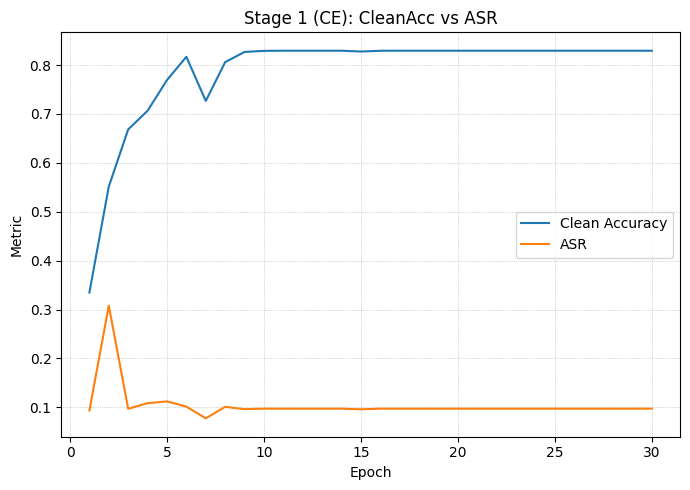

In [4]:

# ---------- Stage 1: CE with hard pseudo-labels ----------
ce_hist_clean, ce_hist_asr, ce_epochs_hist = [], [], []
criterion_ce = nn.CrossEntropyLoss()
optimizer_ce = optim.SGD(student.parameters(), lr=base_lr, momentum=base_momentum, weight_decay=base_wd)
scheduler_ce = optim.lr_scheduler.MultiStepLR(optimizer_ce, milestones=[ce_epochs//2, int(ce_epochs*0.75)], gamma=0.1)

for e in range(1, ce_epochs + 1):
    student.train()
    for imgs, _ in unlabeled_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.no_grad():
            logits_t = teacher(imgs)
            hard_labels = logits_t.argmax(1)  # teacher-guided pseudo-labels
        logits_s = student(imgs)
        loss = criterion_ce(logits_s, hard_labels)
        optimizer_ce.zero_grad(set_to_none=True)
        loss.backward(); optimizer_ce.step()
    scheduler_ce.step()

    ca = _evaluate_clean_acc(student)
    asr = _evaluate_asr(student)
    ce_epochs_hist.append(e); ce_hist_clean.append(ca); ce_hist_asr.append(asr)
    print(f"[CE] Epoch {e:02d}/{ce_epochs} | CleanAcc: {ca*100:.2f}% | ASR: {asr*100:.2f}% | LR: {scheduler_ce.get_last_lr()[0]:.5f}")

# save intermediate student after CE
torch.save({"model_state": student.state_dict()}, "./student_after_CE.pth")

plt.figure(figsize=(7,5))
plt.title("Stage 1 (CE): CleanAcc vs ASR")
plt.xlabel("Epoch"); plt.ylabel("Metric")
plt.plot(ce_epochs_hist, ce_hist_clean, label="Clean Accuracy")
plt.plot(ce_epochs_hist, ce_hist_asr, label="ASR")
plt.grid(True, linestyle=":", linewidth=0.5); plt.legend(); plt.tight_layout(); plt.show()

[KL] Epoch 01/30 | CleanAcc: 72.18% | ASR: 8.03% | LR: 0.01000
[KL] Epoch 02/30 | CleanAcc: 76.79% | ASR: 15.05% | LR: 0.01000
[KL] Epoch 03/30 | CleanAcc: 77.01% | ASR: 7.73% | LR: 0.01000
[KL] Epoch 04/30 | CleanAcc: 79.62% | ASR: 9.50% | LR: 0.01000
[KL] Epoch 05/30 | CleanAcc: 81.65% | ASR: 10.55% | LR: 0.01000
[KL] Epoch 06/30 | CleanAcc: 81.24% | ASR: 7.63% | LR: 0.01000
[KL] Epoch 07/30 | CleanAcc: 78.86% | ASR: 8.83% | LR: 0.01000
[KL] Epoch 08/30 | CleanAcc: 81.15% | ASR: 9.31% | LR: 0.01000
[KL] Epoch 09/30 | CleanAcc: 81.71% | ASR: 11.37% | LR: 0.01000
[KL] Epoch 10/30 | CleanAcc: 80.96% | ASR: 8.55% | LR: 0.01000
[KL] Epoch 11/30 | CleanAcc: 81.22% | ASR: 8.67% | LR: 0.01000
[KL] Epoch 12/30 | CleanAcc: 81.55% | ASR: 10.44% | LR: 0.01000
[KL] Epoch 13/30 | CleanAcc: 79.63% | ASR: 9.07% | LR: 0.01000
[KL] Epoch 14/30 | CleanAcc: 81.84% | ASR: 10.82% | LR: 0.01000
[KL] Epoch 15/30 | CleanAcc: 81.08% | ASR: 7.83% | LR: 0.00100
[KL] Epoch 16/30 | CleanAcc: 82.71% | ASR: 9.38% |

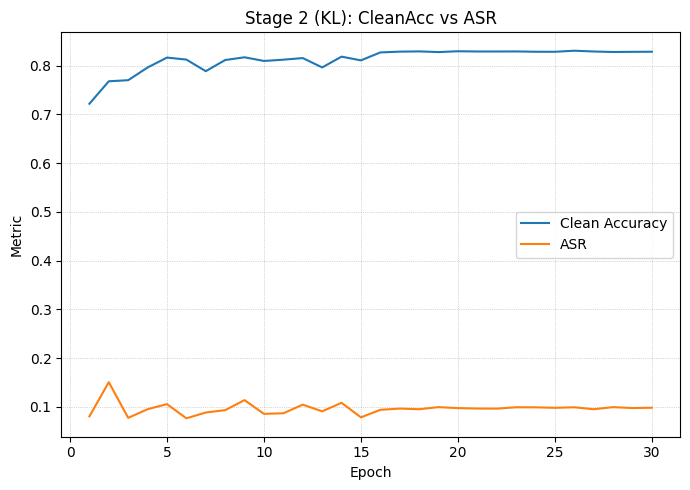

In [5]:
# ---------- Stage 2: KL with soft targets ----------
kl_hist_clean, kl_hist_asr, kl_epochs_hist = [], [], []
kl_loss = nn.KLDivLoss(reduction='batchmean')
optimizer_kl = optim.SGD(student.parameters(), lr=base_lr, momentum=base_momentum, weight_decay=base_wd)
scheduler_kl = optim.lr_scheduler.MultiStepLR(optimizer_kl, milestones=[kl_epochs//2, int(kl_epochs*0.75)], gamma=0.1)

for e in range(1, kl_epochs + 1):
    student.train()
    for imgs, _ in unlabeled_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.no_grad():
            logits_t = teacher(imgs)
            p_t = torch.softmax(logits_t / T, dim=1)
        logits_s = student(imgs)
        log_p_s = torch.log_softmax(logits_s / T, dim=1)
        loss = (T*T) * kl_loss(log_p_s, p_t)
        optimizer_kl.zero_grad(set_to_none=True)
        loss.backward(); optimizer_kl.step()
    scheduler_kl.step()

    ca = _evaluate_clean_acc(student)
    asr = _evaluate_asr(student)
    kl_epochs_hist.append(e); kl_hist_clean.append(ca); kl_hist_asr.append(asr)
    print(f"[KL] Epoch {e:02d}/{kl_epochs} | CleanAcc: {ca*100:.2f}% | ASR: {asr*100:.2f}% | LR: {scheduler_kl.get_last_lr()[0]:.5f}")

# save final student after KL
torch.save({"model_state": student.state_dict()}, "./student_after_KL.pth")

plt.figure(figsize=(7,5))
plt.title("Stage 2 (KL): CleanAcc vs ASR")
plt.xlabel("Epoch"); plt.ylabel("Metric")
plt.plot(kl_epochs_hist, kl_hist_clean, label="Clean Accuracy")
plt.plot(kl_epochs_hist, kl_hist_asr, label="ASR")
plt.grid(True, linestyle=":", linewidth=0.5); plt.legend(); plt.tight_layout(); plt.show()

In [6]:
# ---------- Simple comparison & printout ----------
if len(ce_hist_clean) and len(kl_hist_clean):
    ce_final_clean, ce_final_asr = ce_hist_clean[-1], ce_hist_asr[-1]
    kl_final_clean, kl_final_asr = kl_hist_clean[-1], kl_hist_asr[-1]
    print("=== Distillation Comparison (final epoch of each stage) ===")
    print(f"CE  -> CleanAcc: {ce_final_clean*100:.2f}% | ASR: {ce_final_asr*100:.2f}%")
    print(f"KL  -> CleanAcc: {kl_final_clean*100:.2f}% | ASR: {kl_final_asr*100:.2f}%")
    better_clean = "KL" if kl_final_clean >= ce_final_clean else "CE"
    better_asr = "KL" if kl_final_asr <= ce_final_asr else "CE"
    print(f"Better for CleanAcc: {better_clean}")
    print(f"Better for Lower ASR: {better_asr}")

# You can optionally persist the histories to CSV for your report.


=== Distillation Comparison (final epoch of each stage) ===
CE  -> CleanAcc: 82.93% | ASR: 9.72%
KL  -> CleanAcc: 82.85% | ASR: 9.81%
Better for CleanAcc: CE
Better for Lower ASR: CE
